#  Q2.  Implement the Lloyd's algorithm for k-means (30 points)

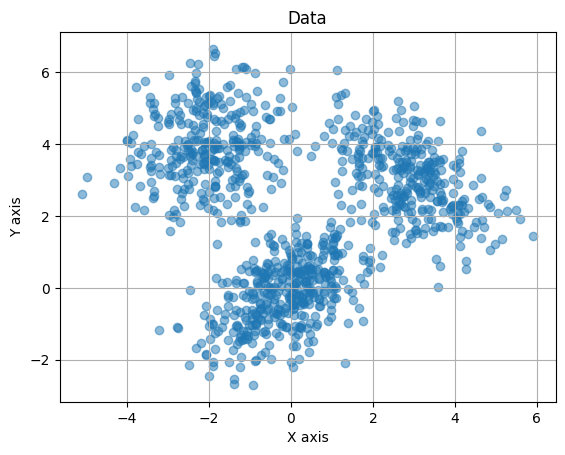

In [1]:
# First generate and visualize the input data


import numpy as np
import matplotlib.pyplot as plt

# Parameters for the mixture components
means = [np.array([0, 0]), np.array([3, 3]), np.array([-2, 4])]
covs = [np.array([[1, 0.5], [0.5, 1]]), np.array([[1, -0.5], [-0.5, 1]]), np.array([[1, 0], [0, 1]])]
weights = [0.4, 0.3, 0.3]  # Must sum to 1
num_samples = 1000

# Generate samples
samples = []
for mean, cov, weight in zip(means, covs, weights):
    num_component_samples = int(weight * num_samples)
    component_samples = np.random.multivariate_normal(mean, cov, num_component_samples)
    samples.append(component_samples)

# Combine samples from all components
data = np.vstack(samples)

# Plot
plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title('Data')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.grid(True)
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_centroids(data, k):
    # Randomly select k data points from the dataset as centroids
    # ==================YOUR CODE HERE =================


    indices = np.random.choice(data.shape[0], k, replace=False)


    return data[indices]

def assign_clusters(data, centroids):
    # Return a vector of integers in {0,1,2,3,...,k-1} to indicate the cluster assignments of data points
    # the vector should be of length as long as the data size

    # ==================YOUR CODE HERE =================

    clusters = np.zeros(data.shape[0], dtype=int)
    for i in range(data.shape[0]):
        distances = np.linalg.norm(data[i] - centroids, axis=1)
        clusters[i] = np.argmin(distances)

    # ==================================================
    return clusters

def update_centroids(data, clusters, k):
    # update the centroids
    # ==================YOUR CODE HERE =================

    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0)
        else:
            new_centroids[i] = data[np.random.choice(data.shape[0])]

    # ==================================================
    return new_centroids

def kmeans(data, k, max_iters=100):
    centroids = initialize_centroids(data, k)
    # Write a for loop to implement the kmeans algorithm
    for _ in range(max_iters):
        # ==================YOUR CODE HERE =================

        clusters = assign_clusters(data, centroids)
        centroids = update_centroids(data, clusters, k)

        # ==================================================
    # return the updated cluster centers
    return centroids, clusters

Centroids: [[-2.06420474  3.97617221]
 [ 2.89973113  3.01793935]
 [-0.17789798 -0.17712978]]


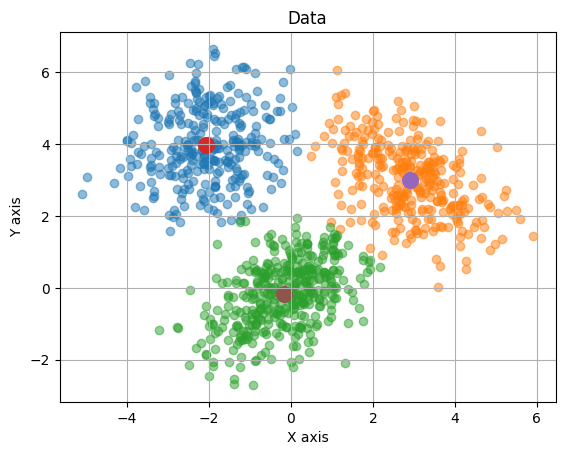

In [11]:
# If your implementation is valid, then the following should generate the clustering in colors.

k=3
centroids, clusters = kmeans(data,k)
print("Centroids:", centroids)
# Plot
colors =  plt.get_cmap("tab10")

for i in range(k):
    plt.scatter(data[clusters==i, 0], data[clusters==i, 1], color=colors(i), alpha=0.5)
for i in range(k):
    plt.scatter(centroids[i,0],centroids[i,1],marker='o',s=128,color=colors(i+k))
plt.title('Data')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.grid(True)
plt.show()


## Next, let's do clustering of a real data set "Olivetti faces".    The same function you implemented above should work on this dataset directly without changes.

1. Do you get the same results each time you run k-means?  Why?  
   No, we do not get the same results each time we run k-means. This is because
   k-means is sensitive to the random initialization of the centroids. If we 
   were to set the random seed, then we should obtain consistent results across
   runs. A random init each run results in a potentially different local
   minima in the objective function, resulting in different clusters.

2. Describe what you see when you adjust k.  You may reorganize the subplot layouts to see clearly.  
   For small `k` (< 10), the centroids are quite blurry as each centroid averages across 
   many different faces. These centroids only capture very broad details such as
   lighting and general face shape. As we increase `k` the centroids become more
   recognizable and start capturing more facial features such as glasses and face
   direction. Once `k` becomes extremely large (25+), each centroid almost represents
   an entirely unique person. The centroids are much more structured and meaningful.

3. What are the prominent differences you can see between the raw images and the "centroid faces"?  
   Raw images are real individual faces, with a clear identity and fine detail.
   The centroid faces are blurry, with more smoothed features (as they are averaged).
   The faces also look more symmetric and even. There are clear differences
   in lighting and key features (glasses, hair, wrinkles, facial shape).



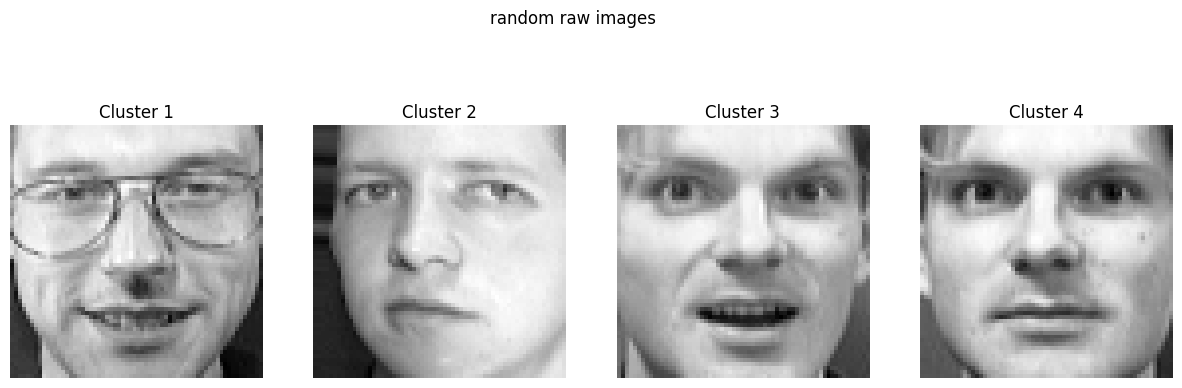

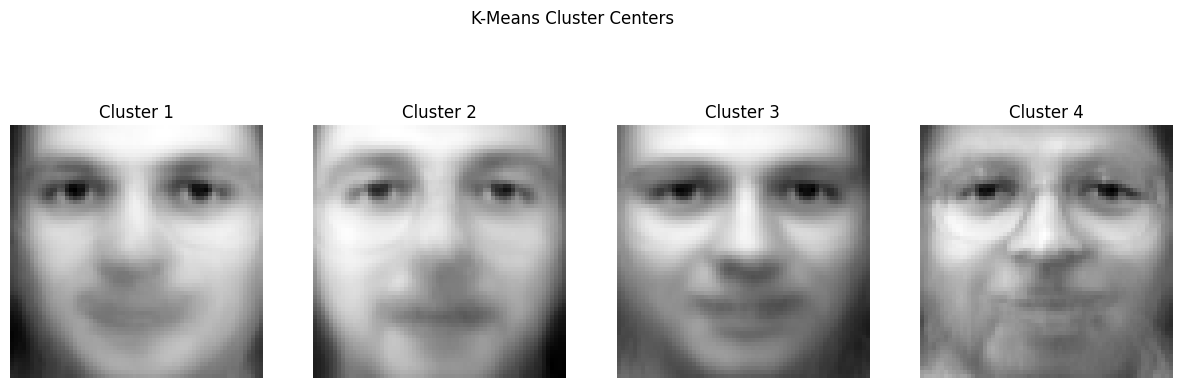

In [15]:
from sklearn.datasets import fetch_olivetti_faces

# We'll fetch the Olivetti faces dataset
data = fetch_olivetti_faces().data

k = 4  # number of clusters

random_imgs = initialize_centroids(data, k)

# Visualize the cluster centers as images
plt.figure(figsize=(15, 5))
for i, centroid in enumerate(random_imgs ):
    plt.subplot(1, k, i + 1)
    plt.imshow(centroid.reshape(64, 64), cmap='gray')
    plt.title(f'Cluster {i+1}')
    plt.axis('off')
plt.suptitle('random raw images')
plt.show()




# Apply K-Means Clustering
centroids, _ = kmeans(data, k)

# Visualize the cluster centers as images
plt.figure(figsize=(15, 5))
for i, centroid in enumerate(centroids):
    plt.subplot(1, k, i + 1)
    plt.imshow(centroid.reshape(64, 64), cmap='gray')
    plt.title(f'Cluster {i+1}')
    plt.axis('off')
plt.suptitle('K-Means Cluster Centers')
plt.show()

